# FNCE 449 Day 5:  Derivatives and Delta-Hedging

## The Cox-Ross-Rubinstein (Binomial) model

1. Consider a call (put) option on a stock maturing after time $T$.
2. The current stock price is $S_0$, strike price is $K$.
3. The volatility of the stock is $\sigma$, risk free rate $r$ .
4. We want to compute the price of the option using a tree with $N$ steps.

### Up-and-down steps (definition)
1. The length of a step is $\Delta t=\dfrac{T}{N}$.
2. At each step the stock moves up by $u$, or down by $d$:
	\begin{align}
	u&=\exp\left(\sigma \sqrt{\Delta t}\right) \\
	d&=u^{-1}
	\end{align}

![alt text](https://github.com/mariuszoican/mgt443/raw/main/Data/Options_F1.png "Title")

### Risk-neutral probabilities

The risk-neutral probability of an upward jump is $p$, where:
\begin{equation}
p=\frac{\exp\left(r\Delta t\right)-d}{u-d}.
\end{equation}


The value of the option at step $k$ is the discounted risk-neutral expectation at $t+1$:

\begin{equation}
C_{k}=\exp\left(-r\Delta t\right)\left[p \times C_{k+1}^{u}+\left(1-p\right) \times  C_{k+1}^d\right]
\end{equation}

### Background

Remember that to price the option at step $k$ we replicate the payoffs at step $k+1$ using $\Delta$ stocks and $B$ bonds:
\begin{align*}
C_{k+1}^{u}&=\Delta u S + \exp\left(r\Delta t\right) B \\
C_{k+1}^{d}&=\Delta d S + \exp\left(r\Delta t\right) B
\end{align*}
Therefore, solving this system:
\begin{align*}
\Delta &= \frac{C_{k+1}^{u}-C_{k+1}^{d}}{\left(u-d\right)S} \\
B &=\frac{u C_{k+1}^{d}- d C_{k+1}^{u}}{\left(u-d\right)\exp\left(r\Delta t\right) }
\end{align*}


The current value of the option is the current value of the stock and bond portfolio:
\begin{equation}
C_{k}=\Delta S + B.
\end{equation}

Replacing the previously found values for $\Delta$ and $B$,
\begin{equation}
C_{k}=\exp\left(-r\Delta t\right)\left[p C_{k+1}^{u}+\left(1-p\right) C_{k+1}^d\right]
\end{equation}

### Algorithm

Inputs:

* $T$ is the time to maturity (in years),
* $N$ is the number of tree steps,
* $S$ is the current stock price,
* $r$ is the risk free rate (net, absolute terms, i.e., 0.03 for 3% p.a.),
* $\sigma$ is annual volatility (absolute terms),
* $K$ is the strike price,
* `typeEA` takes value `European` or `American`, 
* `typeCP` takes value `call` or `put`.


In [1]:
# initialize values
T, N, S, r, sigma, K, typeEA, typeCP = 2, 3, 100, 0.03, 0.20, 110, 'European', 'call'

### Option payoff

1. The call option payoff is $\max (S - K, 0)$ whereas the put option payoff is $\max (K - S; 0)$.
2. We transform the `typeCP` variable from a string to a number: 1 for call options, -1 for put options.
3. Then we can write both the call and put option payoff together:
$$ \text{OptionPayoff} = \max (\text{typeCP} \times  (S - K); 0) $$

In [2]:
if typeCP=="call": # Call or put option
    typeCP=1
elif typeCP=="put":
    typeCP=-1
else:
    print ("Unknown option type")

### Intermediary variables:

In [3]:
import numpy as np
dt=float(T)/N # step size
u=np.exp(sigma*np.sqrt(dt)) # up and down steps
d=1/u


p=(np.exp(r*dt)-d)/(u-d) # risk-neutral probabilities

In [4]:
u,d,p

(np.float64(1.177389048551396),
 np.float64(0.8493369300745177),
 np.float64(0.5208453179499308))

In [5]:
ST=np.zeros(N+1) # Final stock prices vector
option=np.zeros(N+1) # option price vector

In [6]:
option

array([0., 0., 0., 0.])

### Recursive solution: fill in the terminal values

1. The tree has $N$ steps, hence $N + 1$ terminal values for the stock and the option price.
2. Each possible terminal value is a combination of $k$ downward steps and $N-k$ upward steps, where k varies from zero to N.
3. Terminal option prices are just computed using terminal stock prices (no expectation required).

In [7]:
for i in range(0,N+1):
    ST[i]=S*u**(N-i)*d**i # Fill in terminal stock prices
    option[i]=max(typeCP*(ST[i]-K),0) # Fill in terminal option prices

In [8]:
ST, option

(array([163.21496482, 117.73890486,  84.93369301,  61.26889168]),
 array([53.21496482,  7.73890486,  0.        ,  0.        ]))

$S*u^{N-i}*d^i$:

$i=0$: $S*u^N$

$i=1$: $S*u^{N-1}*d$

$i=2$: $S*u^{N-2}*d^2$

....

$i=N$: $S*u^{0}*d^N=S*d^N$


In [9]:
ST

array([163.21496482, 117.73890486,  84.93369301,  61.26889168])

In [10]:
option

array([53.21496482,  7.73890486,  0.        ,  0.        ])

### Moving backwards:

Starting from the vector option of terminal values, loop:
1. Backwards over tree levels ($i$ loop);
2. Forward over cells on a tree level ($j$ loop)
3. At each new tree level, we overwrite the option vector with the discounted expected values of the option on the following level.

![alt text](https://github.com/mariuszoican/mgt443/blob/main/Data/Options_F2.png?raw=true)

Replacing the previously found values for $\Delta$ and $B$,
\begin{equation}
C_{k}=\exp\left(-r\Delta t\right)\left[p C_{k+1}^{u}+\left(1-p\right) C_{k+1}^d\right]
\end{equation}

In [11]:
for i in range(N-1,-1,-1):
    print(i, option)
    for j in range(0,i+1):
        option[j]=np.exp(-r*dt)*(p*option[j]+(1-p)*option[j+1])
    

2 [53.21496482  7.73890486  0.          0.        ]
1 [30.8026431   3.95095772  0.          0.        ]
0 [17.58136519  2.01708991  0.          0.        ]


In [12]:
option

array([9.92320773, 2.01708991, 0.        , 0.        ])

For an American option, at each node $j$ we:
1. Compute the stock price at that node.
2. Compare the European option value with the payoff on immediate exercise (using the stock price we just computed).
3. We keep the largest value of the two.

In [13]:
for i in range(N-1,-1,-1):
    for j in range(0,i+1):
        option[j]=np.exp(-r*dt)*(p*option[j]+(1-p)*option[j+1])
        if typeEA=="American":
            ST[j]=np.exp(-r*dt)*(p*ST[j]+(1-p)*ST[j+1])
            option[j]=max(option[j], max(typeCP*(ST[j]-K),0))

### Binomial tree function

In [14]:
def binomialtree(T,N,S,r,sigma,K, typeEA, typeCP):

    if typeCP=="call": # Call or put option
        typeCP=1
    else:
        typeCP=-1

    dt=float(T)/N # step size
    u=np.exp(sigma*np.sqrt(dt)) # up and down steps
    d=1/u
    p=(np.exp(r*dt)-d)/(u-d) # risk-neutral probabilities

    ST=np.zeros(N+1) # Final stock prices vector
    option=np.zeros(N+1) # option price vector

    for i in range(0,N+1):
        ST[i]=S*u**(N-i)*d**i # Fill in terminal stock prices
        option[i]=max(typeCP*(ST[i]-K),0) # Fill in terminal option prices
    
    for i in range(N-1,-1,-1):
        for j in range(0,i+1):
            option[j]=np.exp(-r*dt)*(p*option[j]+(1-p)*option[j+1])
            if typeEA=="American":
                ST[j]=np.exp(-r*dt)*(p*ST[j]+(1-p)*ST[j+1])
                option[j]=max(option[j], max(typeCP*(ST[j]-K),0))

    return option[0]

In [15]:
S, K, T

(100, 110, 2)

In [16]:
binomialtree(T,N,S,r,sigma,110,'European', "put")

np.float64(13.517306419627017)

## Black-Scholes model for option prices


The Black-Scholes formula for a European call option price $C$ is given by:

$$
C = S \cdot N(d1) - K \cdot e^{-rT} \cdot N(d2)
$$

For a European put option price $P$:

$$
P = K \cdot e^{-rT} \cdot N(-d2) - S \cdot N(-d1)
$$

Where:
- $S$ is the current price of the stock
- $K$ is the strike price of the option
- $T$ is the time to maturity (in years)
- $r$ is the risk-free interest rate
- $\sigma$ (sigma) is the volatility of the stock's returns
- $N(\cdot)$ is the cumulative distribution function of the standard normal distribution

The terms $d1$ and $d$ are calculated as follows:

$$
d1 = \frac{\ln(S/K) + (r + 0.5 \cdot \sigma^2) \cdot T}{\sigma \cdot \sqrt{T}}
$$

$$
d2 = d1 - \sigma \cdot \sqrt{T}
$$

In [17]:
import numpy as np
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt

def BlackScholes(T,S,K,sigma,r,typeCP):
    d1=(np.log(S/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2=d1-sigma*np.sqrt(T)
  
    call=S*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)
    put = K*np.exp(-r*T)*norm.cdf(-d2)- S*norm.cdf(-d1)
  
    if typeCP=='call':
        return call
    else:
        return put

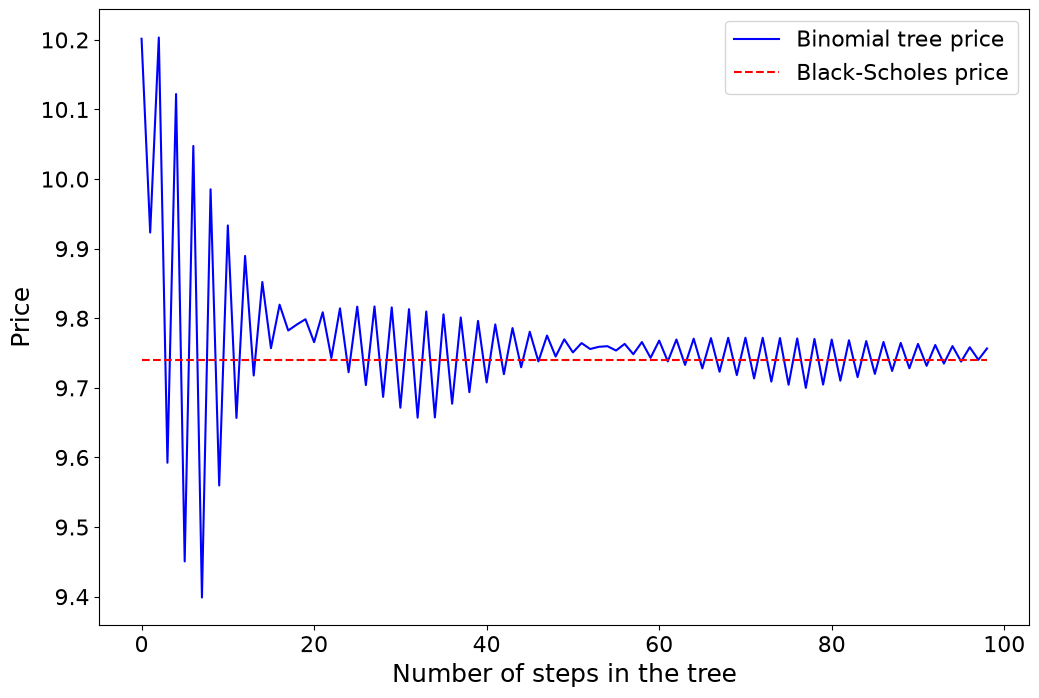

In [18]:
from scipy.stats import norm # we need the Normal distribution functions
import matplotlib.pyplot as plt

N_space=np.linspace(2,100,99) # number of steps in the binomial tree

binomial_space=[binomialtree(T,int(x),S,r,sigma,K,"European", "call") for x in N_space]
BS_space=[BlackScholes(T,S,K,sigma,r,'call') for x in N_space]

fig=plt.figure(figsize=(12,8))
plt.plot(binomial_space,label='Binomial tree price',c='b')
plt.plot(BS_space,label='Black-Scholes price',c='r',ls='--')
plt.xlabel('Number of steps in the tree',fontsize=18)
plt.ylabel('Price',fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16,loc='best')

### Function for option delta ($\Delta$)

Delta is a measure of the sensitivity of the option price to changes in the price of the underlying asset. It represents the rate of change of the option price with respect to changes in the underlying asset's price. 

#### Mathematical Formula

For a call option, Delta ($\Delta_{call}$) is given by:

$$
\Delta_{call} = N(d1)
$$

For a put option, Delta ($\Delta_{put}$) is given by:

$$
\Delta_{put} = N(d1) - 1
$$

Where:
- N(·) is the cumulative distribution function of the standard normal distribution.
- d1 is calculated as:

$$
d1 = \frac{\ln(S/K) + (r + 0.5 \cdot \sigma^2) \cdot T}{\sigma \cdot \sqrt{T}}
$$


In [19]:
def delta(S, K, T, r, sigma, option_type='call'):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    
    if option_type == 'call':
        return norm.cdf(d1)
    elif option_type == 'put':
        return norm.cdf(d1) - 1
    else:
        raise ValueError("Option type must be 'call' or 'put'")

### Initialize simulation and set parameters

In [20]:
# Parameters
S = 100      # Current stock price
K = 100      # Strike price
T = 1        # Time to maturity (1 year)
r = 0.05     # Risk-free interest rate
sigma = 0.2  # Volatility

# Initial delta for a short call option
initial_delta = -delta(S, K, T, r, sigma, option_type='call')
print(f"Initial Delta (Short Call): {initial_delta:.4f}")

Initial Delta (Short Call): -0.6368


## Dynamic $\Delta$-hedging

In [21]:

time_steps = 100
dt = T / time_steps

# Lists to store results
deltas = []
stock_prices = []
option_prices= []

# Initial positions
current_stock_price = S
current_option_price = BlackScholes(T, S, K, sigma, r, 'call')
current_delta = initial_delta

# Simulation of time evolution
for step in range(time_steps + 1):
    current_time = T - step * dt
    current_option_price = BlackScholes(current_time, current_stock_price, K, sigma, r, 'call')
    current_delta = delta(current_stock_price, K, current_time, r, sigma, option_type='call')
    
    deltas.append(current_delta)
    stock_prices.append(current_stock_price)
    option_prices.append(current_option_price)
    
    
    # Update stock price
    current_stock_price *= np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * np.random.normal())

# Create DataFrame to store results
df = pd.DataFrame({
    'Time Step': range(time_steps + 1),
    'Stock Price': stock_prices,
    'Delta': deltas,
    'Option Price': option_prices,
})


# Hedging parameters

contracts=200
contract_size=100 # stock multiplier per option contract

df['Delta_Options']=-contracts*contract_size*df['Delta']
df['Option_ShortExposure']=-contracts*contract_size*df['Option Price']
df['Stocks_Long']=-df['Delta_Options']
df['Stocks_PositionChange']=df['Stocks_Long'].diff()
df.loc[0, 'Stocks_PositionChange'] = df.loc[0, 'Stocks_Long']
df['cost_shares']=df['Stocks_PositionChange']*df['Stock Price']
df['cumulative_cost_shares']=df['cost_shares'].cumsum()
df['interest']=(np.exp(r*dt)-1)*df['cumulative_cost_shares']

df['hedging_cost']=df['cumulative_cost_shares']+df['interest']
df.head()

/var/folders/9k/klys4_hj2w1d7f9j4y2prbwm0000gn/T/ipykernel_87074/3101433273.py:7: RuntimeWarning: divide by zero encountered in scalar divide
  d1=(np.log(S/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
/var/folders/9k/klys4_hj2w1d7f9j4y2prbwm0000gn/T/ipykernel_87074/1625753490.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))


,Time Step,Stock Price,Delta,Option Price,Delta_Options,Option_ShortExposure,Stocks_Long,Stocks_PositionChange,cost_shares,cumulative_cost_shares,interest,hedging_cost
0,0,100.000000,0.636831,10.450584,-12736.613024,-209011.671444,12736.613024,12736.613024,1.273661e+06,1.273661e+06,636.989885,1.274298e+06
1,1,99.750859,0.631455,10.228428,-12629.105797,-204568.568642,12629.105797,-107.507227,-1.072394e+04,1.262937e+06,631.626576,1.263569e+06
2,2,99.103573,0.618293,9.759877,-12365.868460,-195197.542822,12365.868460,-263.237337,-2.608776e+04,1.236850e+06,618.579434,1.237468e+06
3,3,98.900663,0.613553,9.570944,-12271.053086,-191418.886017,12271.053086,-94.815374,-9.377303e+03,1.227472e+06,613.889610,1.228086e+06
4,4,101.068782,0.654383,10.880959,-13087.654151,-217619.184761,13087.654151,816.601065,8.253287e+04,1.310005e+06,655.166365,1.310660e+06


### Plotting the strategy and hedging cost

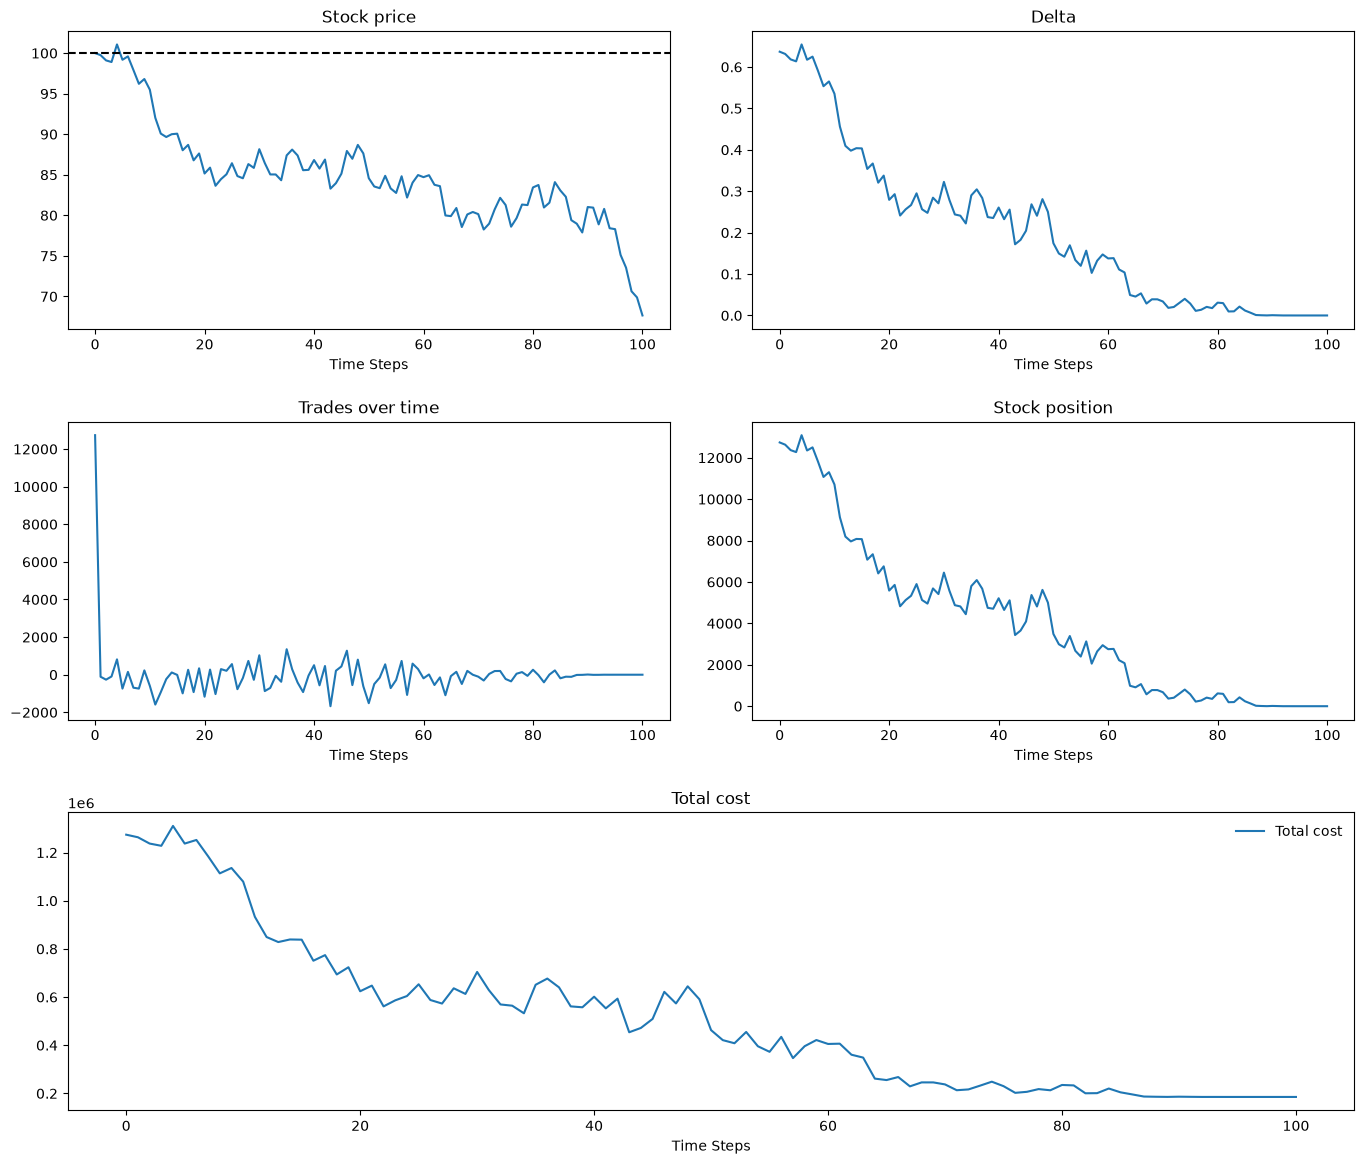

In [22]:
import matplotlib.pyplot as plt # most standard plotting library
import seaborn as sns # a modern plotting library
import matplotlib.gridspec as gridspec # helps with plotting multiple figures
from matplotlib.dates import DateFormatter
import numpy as np

gs=gridspec.GridSpec(3,2)
fig=plt.figure(figsize=(14,12),facecolor='white') # generate a figure of given size

ax=fig.add_subplot(gs[0,0])
plt.plot(df['Stock Price'], label='Stock Price')
plt.axhline(y=K,c='k',ls='--')
plt.title('Stock price')
plt.xlabel('Time Steps')

ax=fig.add_subplot(gs[0,1])
plt.plot(df['Delta'], label='Stock Price')
plt.title('Delta')
plt.xlabel('Time Steps')

ax=fig.add_subplot(gs[1,0])
plt.plot(df['Stocks_PositionChange'], label='Stock Price')
plt.title('Trades over time')
plt.xlabel('Time Steps')

ax=fig.add_subplot(gs[1,1])
plt.plot(df['Stocks_Long'], label='Stock position')
plt.title('Stock position')
plt.xlabel('Time Steps')


ax=fig.add_subplot(gs[2,:])
plt.plot(df['hedging_cost'],label='Total cost')
plt.legend(loc='best',frameon=False)
plt.title('Total cost')
plt.xlabel('Time Steps')

plt.tight_layout(pad=2.0)


In [23]:
print("Hedging cost: ", df.hedging_cost.iloc[-1]-(df['Stock Price'].iloc[-1]>K)*K*contracts*contract_size)
print("End position: ", df.Stocks_Long.iloc[-1])

Hedging cost:  185301.97897118574
End position:  0.0


## Why Binomial Tree? Easy for non-standard options: Try power options instead

Power=$\max(0,S^\alpha-K)$

$P_t=e^{-r\Delta t} \mathbb{E} P_{t+\Delta t}$

In [24]:
def binomialtree_power(T,N,S,r,sigma,K, typeEA, typeCP,power):

    if typeCP=="call": # Call or put option
        typeCP=1
    else:
        typeCP=-1
    
    dt=float(T)/N # step size
    u=np.exp(sigma*np.sqrt(dt)) # up and down steps
    d=1/u
    p=(np.exp(r*dt)-d)/(u-d) # risk-neutral probabilities

    ST=np.zeros(N+1) # Final stock prices vector
    option=np.zeros(N+1) # option price vector

    for i in range(0,N+1):
        ST[i]=S*u**(N-i)*d**i # Fill in terminal stock prices
        # ONLY CHANGE IS HERE
        option[i]=max(typeCP*(ST[i]**power-K),0) # Fill in terminal option prices
    
    for i in range(N-1,-1,-1):
        for j in range(0,i+1):
            option[j]=np.exp(-r*dt)*(p*option[j]+(1-p)*option[j+1])
            if typeEA=="American":
                ST[j]=np.exp(-r*dt)*(p*ST[j]+(1-p)*ST[j+1])
                option[j]=max(option[j], max(typeCP*(ST[j]**power-K),0))

    return option[0]

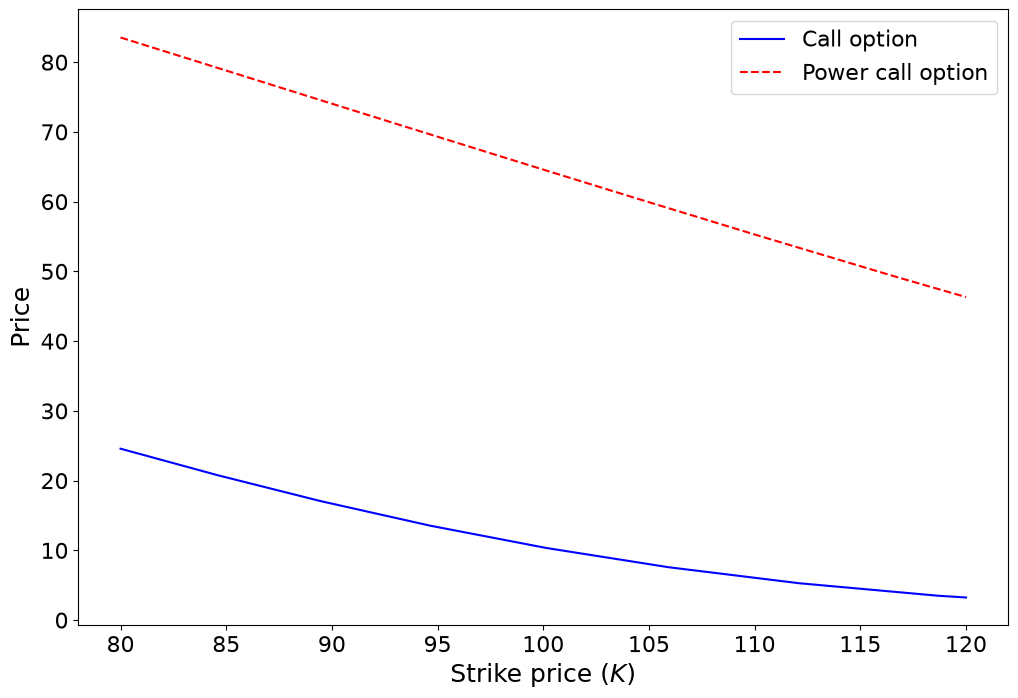

In [25]:
k_space=np.linspace(80,120,1000) # number of stepts in the binomial tree

call_K_space=[binomialtree(T,50,S,r,sigma,ki,typeEA, "call") for ki in k_space]
call_K_space_pow=[binomialtree_power(T,50,S,r,sigma,ki,typeEA,"call",1.1) for ki in k_space]

fig=plt.figure(figsize=(12,8))
plt.plot(k_space, call_K_space ,label='Call option',c='b')
plt.plot(k_space, call_K_space_pow ,label='Power call option',c='r',ls='--')
plt.xlabel('Strike price ($K$)',fontsize=18)
plt.ylabel('Price',fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16,loc='best')

## Monte Carlo simulation (static, plain vanilla call & put)

1. Simulate a large number ($N$) of terminal stock prices.
2. Compute the option value for each terminal stock price.
3. Take the average across all $N$.
4. The method is simple and intuitive. It requires two assumptions:
  * The option is European (only exercised at maturity)
  * The option payoff depends only on final stock prices.
5. Useful method for plain vanilla calls and puts.

If we assume the stock price follows a geometric brownian motion (the same process underlying Black-Scholes):

\begin{equation}
dS_t=r S_t \times dt+ \sigma S_t \times dz_t
\end{equation}

The value of the stock at time $T$, $S_T$ is: 
$$S_T = S_0 e^{\left(r-\frac{1}{2}\sigma^2\right) T + \sigma \sqrt{T} z}, $$
where $z$ is a standard normal variable (i.e., random). 

All we need to do then is simulate a large number of $z$:
1. Compute terminal values of $S_T$ corresponding to each $z$;
2. Compute option payoffs corresponding to each $S_T$;
3. Average terminal option payoffs, and discount them to time zero (i.e., multiply by $e^{-rT}$). 

In [26]:
import numpy.random as npr
N=10
z=npr.randn(N)
ST = S*np.exp((r-0.5*sigma**2)*T+sigma*np.sqrt(T)*z)
ST

array([118.48284344, 108.73120393, 102.05626795,  99.17549116,
       113.5337132 , 111.44936559,  93.84186692, 112.24547685,
       115.12486626, 135.67663236])

<Axes: ylabel='Count'>

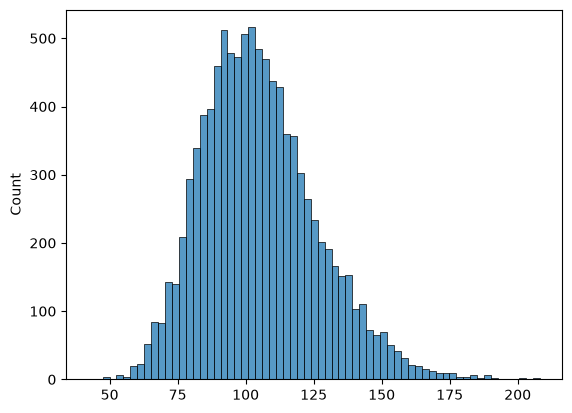

In [27]:
import numpy.random as npr
N=10000
z=npr.randn(N)
ST = S*np.exp((r-0.5*sigma**2)*T+sigma*np.sqrt(T)*z)
sns.histplot(ST)

In [28]:
K=100
OptionT= np.maximum(typeCP*(ST - K), 0)
OptionT, OptionT.mean()

(array([ 0.        , 13.26039281, 16.04408334, ...,  4.63185843,
         6.13547319, 21.95386833], shape=(10000,)),
 np.float64(10.880281884197986))

In [29]:
# discounted present value
np.exp(-r*T)*OptionT.mean()

np.float64(10.349644275111194)

In [30]:
def montecarlo(T,N,S,r,sigma,K,typeCP):

    if typeCP=="call":
        typeCP=1
    else:
        typeCP=-1

    z = npr.randn(N)
    # simulate index level at maturity
    ST = S*np.exp((r-0.5*sigma**2)*T+sigma*np.sqrt(T)*z)
    # calculate payoff at maturity
    OptionT= np.maximum(typeCP*(ST - K), 0)
    option = np.exp(-r*T)*OptionT.mean()
    return option

### How does Monte Carlo stack up against Black-Scholes?

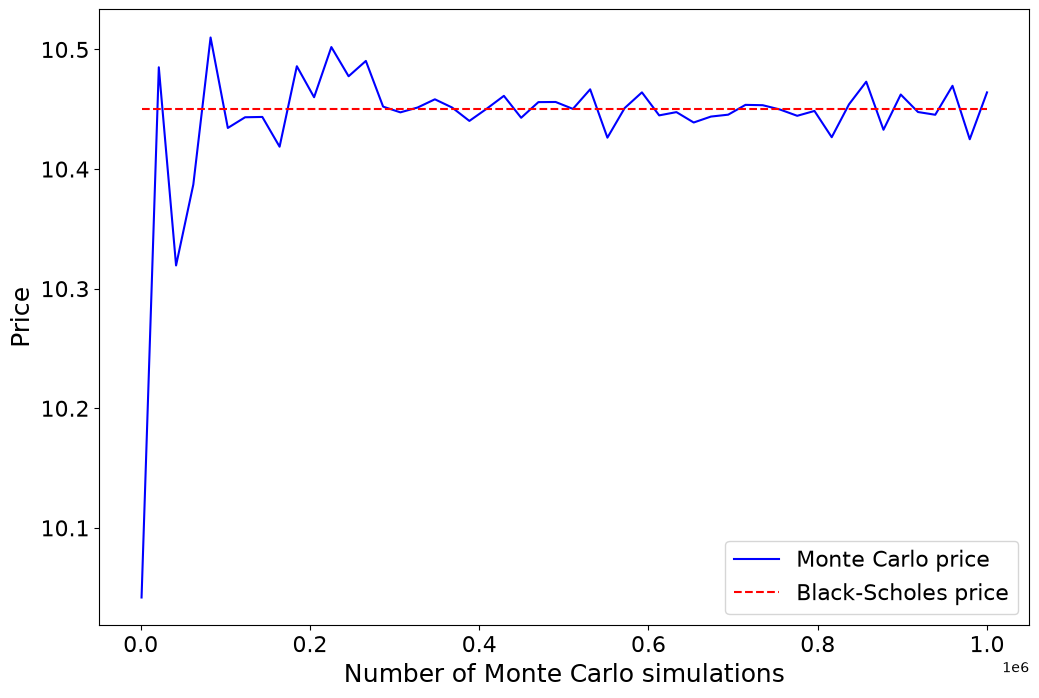

In [31]:
N_space=np.linspace(1000,1000000) # number of simulations

mc_space=[montecarlo(T,int(x),S,r,sigma,K, "call") for x in N_space]
BS_space=[BlackScholes(T,S,K,sigma,r,'call') for x in N_space]

fig=plt.figure(figsize=(12,8))
plt.plot(N_space,mc_space,label='Monte Carlo price',c='b')
plt.plot(N_space, BS_space,label='Black-Scholes price',c='r',ls='--')
plt.xlabel('Number of Monte Carlo simulations',fontsize=18)
plt.ylabel('Price',fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=16,loc='best')

An Asian option (or average value option) is a special type of option contract. For Asian options the payoff is determined by the average underlying price over some pre-set period of time. 
$$c_\text{asian,T}=\max\left\{\text{average}_{0\leq t\leq T} S_t- K, 0 \right\}$$
How to price this contract with Monte Carlo simulations?

In [32]:
def montecarlo_asian(T,N,steps,S,r,sigma,K,typeCP):

    if typeCP=="call":
        typeCP=1
    else:
        typeCP=-1

    dt=float(T)/steps

    SPath=np.zeros((steps+1,N)) # matrix of N paths
    SPath[0]=S # first value is S for all paths
    for t in range(1,steps+1):
        z = npr.randn(N) # random noise for all paths at time t
        SPath[t]=SPath[t-1]*np.exp((r-0.5*sigma**2)*dt+sigma*np.sqrt(dt)*z)
    # calculate payoff at maturity
    
    OptionT= np.maximum(typeCP*(SPath.mean(axis=0)-K), 0)
    
    option = np.exp(-r*T)*OptionT.mean()
    return option

In [33]:
N=4
steps=3

dt=float(T)/steps

SPath=np.zeros((steps+1,N)) # matrix of N paths
SPath[0]=S # first value is S for all paths
for t in range(1,steps+1):
    z = npr.randn(N) # random noise for all paths at time t
    SPath[t]=SPath[t-1]*np.exp((r-0.5*sigma**2)*dt+sigma*np.sqrt(dt)*z)

In [34]:
SPath.mean(axis=0)

array([ 95.375029  , 130.46514929, 117.26118562, 100.76974416])

In [35]:
OptionT= np.maximum(typeCP*(SPath.mean(axis=0)-K), 0)
OptionT

array([ 0.        , 30.46514929, 17.26118562,  0.76974416])

In [36]:
np.exp(-r*T)*OptionT.mean()

np.float64(11.532724344308134)